# Проект "Рынок видеоигр"

- Автор: Хожайнов Даниил Александрович
- Дата: 03.03.2026

### Цели и задачи проекта

В этой тетрадке используем датасет new_games.csv, который содержит информацию о продажах игр разных жанров и платформ, а также пользовательские и экспертные оценки игр.Основная цель - познакомиться с данными, проверить их корректность и провести предобработку, получив необходимый срез данных. Отобрать данные по времени выхода игры. Категоризовать игры по оценкам пользователей и экспертов.

### Описание данных

Датасет содержит информацию о продажах игр разных жанров и платформ, а также пользовательские и экспертные оценки игр:

`Name` — название игры;  
`Platform` — название платформы.  
`Year of Release` — год выпуска игры.  
`Genre` — жанр игры.  
`NA sales` — продажи в Северной Америке (в миллионах проданных копий).  
`EU sales` — продажи в Европе (в миллионах проданных копий).  
`JP sales` — продажи в Японии (в миллионах проданных копий).  
`Other sales` — продажи в других странах (в миллионах проданных копий).  
`Critic Score` — оценка критиков (от 0 до 100).  
`User Score` — оценка пользователей (от 0 до 10).  
`Rating` — рейтинг организации ESRB  

### Содержимое проекта



1. Загрузка и знакомство с данными
2. Проверка ошибок в данных и их предобработка
3. Фильтрация данных
4. Категоризация данных
---

## 1. Загрузка данных и знакомство с ними

Загрузим необходимые библиотеки для анализа данных и данные из датасета `/datasets/new_games.csv`. Затем выведем основную информацию о данных с помощью метода info() и первые строки датафрейма.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('https://code.s3.yandex.net/datasets/new_games.csv')
df.head()

,Name,Platform,Year of Release,Genre,NA sales,EU sales,JP sales,Other sales,Critic Score,User Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16956 entries, 0 to 16955
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16954 non-null  object 
 1   Platform         16956 non-null  object 
 2   Year of Release  16681 non-null  float64
 3   Genre            16954 non-null  object 
 4   NA sales         16956 non-null  float64
 5   EU sales         16956 non-null  object 
 6   JP sales         16956 non-null  object 
 7   Other sales      16956 non-null  float64
 8   Critic Score     8242 non-null   float64
 9   User Score       10152 non-null  object 
 10  Rating           10085 non-null  object 
dtypes: float64(4), object(7)
memory usage: 1.4+ MB
None


In [4]:
df.isna().sum()

Name                  2
Platform              0
Year of Release     275
Genre                 2
NA sales              0
EU sales              0
JP sales              0
Other sales           0
Critic Score       8714
User Score         6804
Rating             6871
dtype: int64

## Выводы о полученных данных

1. Датафрейм представлен в виде таблицы размером: 16956 строк и 11 столбцов. 
2. Данные содержат пропуски : Name(2), Year of Release(275), Critic Score(8714), User Score(6804), Rating (6871)
3. Изучим типы данных и их корректность:

`Name` - object, верный тип данных

`Platform` - object, верный тип данных 

`Year of Release` -  float64, было бы рациональнее представить его как тип даты, а не числа с плавающей точкой.

`Genre` - object, верный тип данных

`NA sales` - float64, продажи в млн, тип данных верный

`EU sales`, `JP sales` - тоже что и выше, необходимо привести к типу данных float64  

`Other sales` - float64, продажи в млн, тип данных верный

`Critic Score `, `User Score` - оценки критиков и пользователей, необходимо привести к типу данных float64

`Rating`- верный тип данных

---

## 2.  Проверка ошибок в данных и их предобработка


### 2.1. Названия, или метки, столбцов датафрейма

- Выведите на экран названия всех столбцов датафрейма и проверьте их стиль написания.
- Приведите все столбцы к стилю snake case. Названия должны быть в нижнем регистре, а вместо пробелов — подчёркивания.

In [5]:
#изучаем названия столбцов
print(df.columns.tolist())

['Name', 'Platform', 'Year of Release', 'Genre', 'NA sales', 'EU sales', 'JP sales', 'Other sales', 'Critic Score', 'User Score', 'Rating']


In [6]:
#изучаем названия отредактированных столбцов
df = df.rename(columns=lambda col: col.lower().replace(' ', '_').replace('-', '_'))
print(df.columns.tolist())

['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating']


### 2.2. Типы данных

- Если встречаются некорректные типы данных, предположите их причины.
- При необходимости проведите преобразование типов данных. Помните, что столбцы с числовыми данными и пропусками нельзя преобразовать к типу `int64`. Сначала вам понадобится обработать пропуски, а затем преобразовать типы данных.

In [7]:
#В столбце года релиза данные хранятся в типе float64, приведем их к типу даты
df['year_of_release'] = pd.to_datetime(df['year_of_release'], format='%Y', errors='coerce')

for i in ['eu_sales', 'jp_sales', 'user_score']:
    df[i] = pd.to_numeric(df[i], errors='coerce')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16956 entries, 0 to 16955
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   name             16954 non-null  object        
 1   platform         16956 non-null  object        
 2   year_of_release  16681 non-null  datetime64[ns]
 3   genre            16954 non-null  object        
 4   na_sales         16956 non-null  float64       
 5   eu_sales         16950 non-null  float64       
 6   jp_sales         16952 non-null  float64       
 7   other_sales      16956 non-null  float64       
 8   critic_score     8242 non-null   float64       
 9   user_score       7688 non-null   float64       
 10  rating           10085 non-null  object        
dtypes: datetime64[ns](1), float64(6), object(4)
memory usage: 1.4+ MB


- В числовых столбцах могут встретиться строковые значения, например `unknown` или другие. Приводите такие столбцы к числовому типу данных, заменив строковые значения на пропуски.

### 2.3. Наличие пропусков в данных

- Посчитайте количество пропусков в каждом столбце в абсолютных и относительных значениях.


In [8]:
missing_percentage = round(df.isna().sum() / len(df) * 100,2) 
missing_df = pd.DataFrame({
    'Количество пропусков': df.isna().sum(),
    'Процент пропусков (%)': missing_percentage
})
print("\nАнализ пропущенных значений:")
display(missing_df)


Анализ пропущенных значений:


,Количество пропусков,Процент пропусков (%)
name,2,0.01
platform,0,0.00
year_of_release,275,1.62
genre,2,0.01
na_sales,0,0.00
eu_sales,6,0.04
jp_sales,4,0.02
other_sales,0,0.00
critic_score,8714,51.39
user_score,9268,54.66


Больше всего пропусков присутствует в столбцах с оценками, более половины значений в каждом стобце пропущены. Возможно это связано с нежеланием пользователя или критика оценивать ту или иную игру. Также не во всех играх проставлен рейтинг организации ESRB. В остальных столбцах доля пропусков составляет менее 0.2%, изучим их.

- Изучите данные с пропущенными значениями. Напишите промежуточный вывод: для каких столбцов характерны пропуски и сколько их. Предположите, почему пропуски могли возникнуть. Укажите, какие действия с этими данными можно сделать и почему.


In [9]:
df[df['name'].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
661,NaN,GEN,1993-01-01,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14439,NaN,GEN,1993-01-01,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN


Всего 2 пропуска в столбце с именем игры и жанра, удалим их, это не вызовет искажение данных.

In [10]:
df.dropna(subset=['name', 'genre'], inplace=True)

- Обработайте пропущенные значения. Для каждого случая вы можете выбрать оптимальный, на ваш взгляд, вариант: заменить на определённое значение, оставить как есть или удалить.
- Если вы решите заменить пропуски на значение-индикатор, то убедитесь, что предложенное значение не может быть использовано в данных.
- Если вы нашли пропуски в данных с количеством проданных копий игры в том или ином регионе, их можно заменить на среднее значение в зависимости от названия платформы и года выхода игры.

In [11]:
df[df['eu_sales'].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
446,Rhythm Heaven,DS,2008-01-01,Misc,0.55,NaN,1.93,0.13,83.0,9.0,E
802,Dead Rising,X360,2006-01-01,Action,1.16,NaN,0.08,0.20,85.0,7.6,M
1131,Prince of Persia: Warrior Within,PS2,2004-01-01,Action,0.54,NaN,0.00,0.22,83.0,8.5,M
1132,Far Cry 4,XOne,2014-01-01,Shooter,0.80,NaN,0.01,0.14,82.0,7.5,M
1394,Sonic Advance 3,GBA,2004-01-01,Platform,0.74,NaN,0.08,0.06,79.0,8.4,E
1612,Ratatouille,DS,2007-01-01,Action,0.49,NaN,0.00,0.14,NaN,NaN,NaN


In [12]:
#Заполняем пропуски средним значением по группе (platform, year_of_release)
def mean_group_eu(row):
    if pd.isna(row['eu_sales']):
        group = df[(df['platform'] == row['platform']) & 
                   (df['year_of_release'] == row['year_of_release'])]
        return group['eu_sales'].mean()
    else:
        return row['eu_sales']

df['eu_sales'] = df.apply(mean_group_eu, axis=1)


In [13]:
df[df['jp_sales'].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
467,Saints Row 2,X360,2008-01-01,Action,1.94,0.79,NaN,0.28,81.0,8.1,M
819,UFC 2009 Undisputed,X360,2009-01-01,Fighting,1.48,0.39,NaN,0.19,83.0,7.9,T
1379,Hello Kitty Party,DS,2007-01-01,Misc,0.78,0.51,NaN,0.12,NaN,NaN,E
4732,Castlevania: The Dracula X Chronicles,PSP,2007-01-01,Platform,0.22,0.09,NaN,0.07,80.0,7.8,T


In [14]:
#Аналогично с продажами в Японии
def mean_group_jp(row):
    if pd.isna(row['jp_sales']):
        group = df[(df['platform'] == row['platform']) &
                (df['year_of_release'] == row['year_of_release'])]
        return group['jp_sales'].mean()
    else:
        return row['jp_sales']

df['jp_sales'] = df.apply(mean_group_jp, axis=1)
    
df.isna().mean()
        

name               0.000000
platform           0.000000
year_of_release    0.016220
genre              0.000000
na_sales           0.000000
eu_sales           0.000000
jp_sales           0.000000
other_sales        0.000000
critic_score       0.513861
user_score         0.546538
rating             0.405155
dtype: float64

In [15]:
#Изучаем данные с неуказанной датой релиза
df[df['year_of_release'].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
183,Madden NFL 2004,PS2,NaT,Sports,4.26,0.26,0.01,0.71,94.0,8.5,E
379,FIFA Soccer 2004,PS2,NaT,Sports,0.59,2.36,0.04,0.51,84.0,6.4,E
458,LEGO Batman: The Videogame,Wii,NaT,Action,1.80,0.97,0.00,0.29,74.0,7.9,E10+
477,wwe Smackdown vs. Raw 2006,PS2,NaT,Fighting,1.57,1.02,0.00,0.41,NaN,NaN,NaN
611,Space Invaders,2600,NaT,Shooter,2.36,0.14,0.00,0.03,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16609,PDC World Championship Darts 2008,PSP,NaT,Sports,0.01,0.00,0.00,0.00,43.0,NaN,E10+
16641,Freaky Flyers,GC,NaT,Racing,0.01,0.00,0.00,0.00,69.0,6.5,T
16685,Inversion,PC,NaT,Shooter,0.01,0.00,0.00,0.00,59.0,6.7,M
16695,Hakuouki: Shinsengumi Kitan,PS3,NaT,Adventure,0.01,0.00,0.00,0.00,NaN,NaN,NaN


Большая часть игр с пропущенным значением релиза являются малоизвестными и низкопродаваемыми. При этом их доля составляет менее 0.2%. Удаляем их. 

In [16]:
df.dropna(subset=['year_of_release'], inplace=True)
df.isna().mean()

name               0.000000
platform           0.000000
year_of_release    0.000000
genre              0.000000
na_sales           0.000000
eu_sales           0.000000
jp_sales           0.000000
other_sales        0.000000
critic_score       0.515259
user_score         0.546855
rating             0.406379
dtype: float64

### 2.4. Явные и неявные дубликаты в данных

- Изучите уникальные значения в категориальных данных, например с названиями жанра игры, платформы, рейтинга и года выпуска. Проверьте, встречаются ли среди данных неявные дубликаты, связанные с опечатками или разным способом написания.
- При необходимости проведите нормализацию данных с текстовыми значениями. Названия или жанры игр можно привести к нижнему регистру, а названия рейтинга — к верхнему.

In [17]:
#Изучаем уникальные значения в категориальных данных
unique_genre = df['genre'].unique()
print(unique_genre)

['Sports' 'Platform' 'Racing' 'Role-Playing' 'Puzzle' 'Misc' 'Shooter'
 'Simulation' 'Action' 'Fighting' 'Adventure' 'Strategy' 'MISC'
 'ROLE-PLAYING' 'RACING' 'ACTION' 'SHOOTER' 'FIGHTING' 'SPORTS' 'PLATFORM'
 'ADVENTURE' 'SIMULATION' 'PUZZLE' 'STRATEGY']


In [18]:
unique_platform = df['platform'].unique()
print(unique_platform)

['Wii' 'NES' 'GB' 'DS' 'X360' 'PS3' 'PS2' 'SNES' 'GBA' 'PS4' '3DS' 'N64'
 'PS' 'XB' 'PC' '2600' 'PSP' 'XOne' 'WiiU' 'GC' 'GEN' 'DC' 'PSV' 'SAT'
 'SCD' 'WS' 'NG' 'TG16' '3DO' 'GG' 'PCFX']


In [19]:
unique_date = df['year_of_release'].unique()
print(unique_date)

<DatetimeArray>
['2006-01-01 00:00:00', '1985-01-01 00:00:00', '2008-01-01 00:00:00',
 '2009-01-01 00:00:00', '1996-01-01 00:00:00', '1989-01-01 00:00:00',
 '1984-01-01 00:00:00', '2005-01-01 00:00:00', '1999-01-01 00:00:00',
 '2007-01-01 00:00:00', '2010-01-01 00:00:00', '2013-01-01 00:00:00',
 '2004-01-01 00:00:00', '1990-01-01 00:00:00', '1988-01-01 00:00:00',
 '2002-01-01 00:00:00', '2001-01-01 00:00:00', '2011-01-01 00:00:00',
 '1998-01-01 00:00:00', '2015-01-01 00:00:00', '2012-01-01 00:00:00',
 '2014-01-01 00:00:00', '1992-01-01 00:00:00', '1997-01-01 00:00:00',
 '1993-01-01 00:00:00', '1994-01-01 00:00:00', '1982-01-01 00:00:00',
 '2016-01-01 00:00:00', '2003-01-01 00:00:00', '1986-01-01 00:00:00',
 '2000-01-01 00:00:00', '1995-01-01 00:00:00', '1991-01-01 00:00:00',
 '1981-01-01 00:00:00', '1987-01-01 00:00:00', '1980-01-01 00:00:00',
 '1983-01-01 00:00:00']
Length: 37, dtype: datetime64[ns]


In [20]:
df['name'] = df['name'].str.lower().str.strip()
df['genre'] = df['genre'].str.lower().str.strip()
df['rating'] = df['rating'].str.upper()
unique_name = df['name'].nunique()
print(unique_name)

11426


После того, как мы привели названия игр и жанров к нижнему регистру, а рейтинга к верхнему, мы подсчитали количество уникальных значений в названии игр, что по сути является первичным ключом, их оказалось 11426, что может говорить о наличиии дубликатов

In [21]:
#Удаляем явные дубликаты
df_clean = df.drop_duplicates(subset=['name', 'genre', 'platform']).copy()

In [22]:
df_clean.shape[0]

16441

In [23]:
n_initial = 16956 #Исходное количество строк
n_final = len(df_clean)
n_removed = n_initial - n_final
percent_removed = (n_removed / n_initial) * 100


print(f"Осталось строк: {n_final}")
print(f"Удалено строк: {n_removed} (абсолютное значение)")
print(f"Удалено: {percent_removed:.2f}% от исходного объёма")

Осталось строк: 16441
Удалено строк: 515 (абсолютное значение)
Удалено: 3.04% от исходного объёма


После предобработки, удаления дубликатов и строк с пропущенными значениями было удалено 515 строк, что составляет 3% от общего количества строк. Основное количество удаленных строк пришлось на неявные дубликаты.

---

## 3. Фильтрация данных

Коллеги хотят изучить историю продаж игр в начале XXI века, и их интересует период с 2000 по 2013 год включительно. Отберите данные по этому показателю. Сохраните новый срез данных в отдельном датафрейме, например `df_actual`.

In [24]:
df_clean.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,wii sports,Wii,2006-01-01,sports,41.36,28.96,3.77,8.45,76.0,8.0,E
1,super mario bros.,NES,1985-01-01,platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,mario kart wii,Wii,2008-01-01,racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,wii sports resort,Wii,2009-01-01,sports,15.61,10.93,3.28,2.95,80.0,8.0,E
4,pokemon red/pokemon blue,GB,1996-01-01,role-playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [25]:
#приводим строку с датой к удобному формату и типу datetime
df_clean['year_of_release'] = pd.to_datetime(df['year_of_release'], format='%Y')
df_clean.info()
df_clean.head()

<class 'pandas.core.frame.DataFrame'>
Index: 16441 entries, 0 to 16955
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   name             16441 non-null  object        
 1   platform         16441 non-null  object        
 2   year_of_release  16441 non-null  datetime64[ns]
 3   genre            16441 non-null  object        
 4   na_sales         16441 non-null  float64       
 5   eu_sales         16441 non-null  float64       
 6   jp_sales         16441 non-null  float64       
 7   other_sales      16441 non-null  float64       
 8   critic_score     7980 non-null   float64       
 9   user_score       7460 non-null   float64       
 10  rating           9765 non-null   object        
dtypes: datetime64[ns](1), float64(6), object(4)
memory usage: 1.5+ MB


,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,wii sports,Wii,2006-01-01,sports,41.36,28.96,3.77,8.45,76.0,8.0,E
1,super mario bros.,NES,1985-01-01,platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,mario kart wii,Wii,2008-01-01,racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,wii sports resort,Wii,2009-01-01,sports,15.61,10.93,3.28,2.95,80.0,8.0,E
4,pokemon red/pokemon blue,GB,1996-01-01,role-playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [26]:
#применяем условия фильтрации:
df_actual = df_clean[
    (df_clean['year_of_release'] >= '2000-01-01') &
    (df_clean['year_of_release'] <= '2013-12-31')
].copy()
df_actual.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,wii sports,Wii,2006-01-01,sports,41.36,28.96,3.77,8.45,76.0,8.0,E
2,mario kart wii,Wii,2008-01-01,racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,wii sports resort,Wii,2009-01-01,sports,15.61,10.93,3.28,2.95,80.0,8.0,E
6,new super mario bros.,DS,2006-01-01,platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,wii play,Wii,2006-01-01,misc,13.96,9.18,2.93,2.84,58.0,6.6,E


---

## 4. Категоризация данных
    
Проведите категоризацию данных:
- Разделите все игры по оценкам пользователей и выделите такие категории: высокая оценка (от 8 до 10 включительно), средняя оценка (от 3 до 8, не включая правую границу интервала) и низкая оценка (от 0 до 3, не включая правую границу интервала).

В предыдущих шагах мы выяснили, что в полях с оценками почти половина значений пропущены, пропущенные значения заменим на -1, т.к. 0 попадает в категорию с низкой оценкой.


In [27]:
#проверим минмальные оценки по каждой категории:
print(df_actual['critic_score'].min())
print(df_actual['user_score'].min())

13.0
0.0


In [28]:
#заменяем все пропущенные значения на -1 и применяем категоризацию 
df_actual['critic_score'] = df_actual['critic_score'].fillna(-1)
df_actual['user_score'] = df_actual['user_score'].fillna(-1)
df_actual['user_score_cut'] = pd.cut(df_actual['user_score'],  
                                     bins=[-1, 0, 3, 8, 11], 
                                     labels=["Нет оценки", "низкая оценка", "средняя оценка", "Высокая оценка"], 
                                     include_lowest=True,
                                     right=False)


- Разделите все игры по оценкам критиков и выделите такие категории: высокая оценка (от 80 до 100 включительно), средняя оценка (от 30 до 80, не включая правую границу интервала) и низкая оценка (от 0 до 30, не включая правую границу интервала).

In [29]:
df_actual['critic_score_cut'] = pd.cut(df_actual['critic_score'],  
                                     bins=[-1, 0, 30, 80, 101], 
                                     labels=["Нет оценки", "низкая оценка", "средняя оценка", "Высокая оценка"], 
                                     include_lowest=True,
                                     right=False)

In [30]:
df_actual.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,user_score_cut,critic_score_cut
0,wii sports,Wii,2006-01-01,sports,41.36,28.96,3.77,8.45,76.0,8.0,E,Высокая оценка,средняя оценка
2,mario kart wii,Wii,2008-01-01,racing,15.68,12.76,3.79,3.29,82.0,8.3,E,Высокая оценка,Высокая оценка
3,wii sports resort,Wii,2009-01-01,sports,15.61,10.93,3.28,2.95,80.0,8.0,E,Высокая оценка,Высокая оценка
6,new super mario bros.,DS,2006-01-01,platform,11.28,9.14,6.50,2.88,89.0,8.5,E,Высокая оценка,Высокая оценка
7,wii play,Wii,2006-01-01,misc,13.96,9.18,2.93,2.84,58.0,6.6,E,средняя оценка,средняя оценка


user_score_cut
Нет оценки        6298
низкая оценка      116
средняя оценка    4080
Высокая оценка    2284
Name: name, dtype: int64


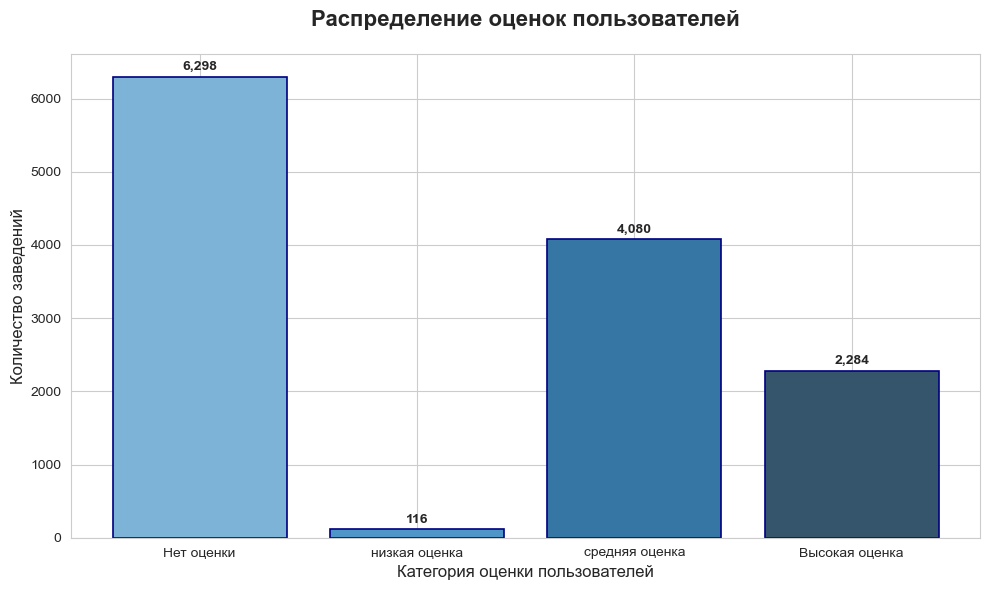

In [31]:
#Проведем группировку по категориям отзывов пользователей
user_score_cut_group = df_actual.groupby('user_score_cut', observed=True)['name'].count()
print(user_score_cut_group)

# Устанавливаем стиль
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# Создаём диаграмму с градиентными цветами
colors = sns.color_palette("Blues_d", len(user_score_cut_group))
bars = plt.bar(user_score_cut_group.index, user_score_cut_group.values,
           color=colors, edgecolor='navy', linewidth=1.2)

# Настройки графика
plt.title('Распределение оценок пользователей', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Категория оценки пользователей', fontsize=12)
plt.ylabel('Количество заведений', fontsize=12)

# Добавляем значения над столбцами
for i, v in enumerate(user_score_cut_group.values):
    plt.text(i, v + 50, f'{v:,}', ha='center', va='bottom',
             fontweight='bold', fontsize=10)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

critic_score_cut
Нет оценки        5612
низкая оценка       55
средняя оценка    5422
Высокая оценка    1689
Name: name, dtype: int64


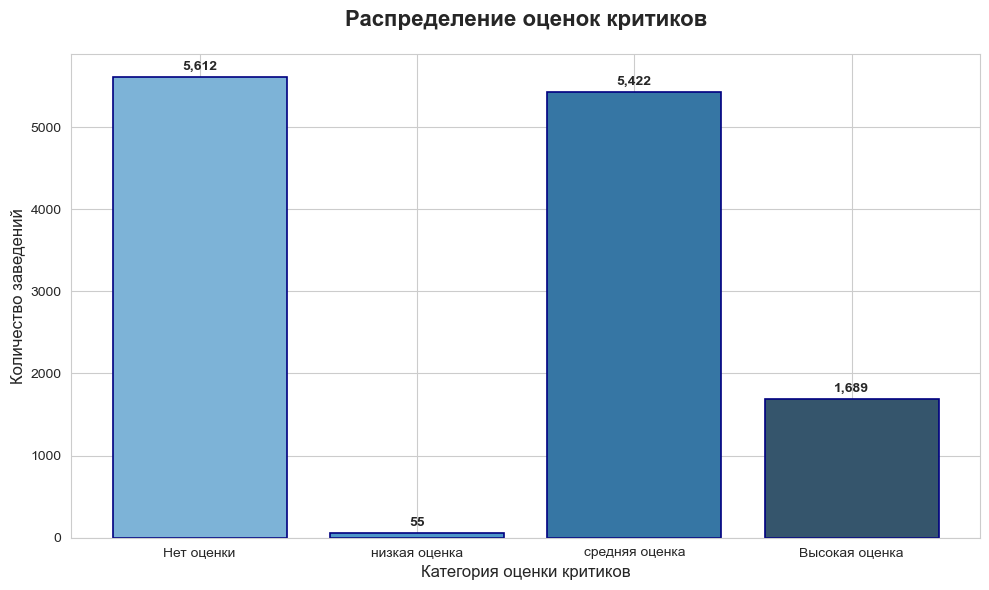

In [32]:
#Проведем группировку по категориям отзывов критиков
critic_score_cut_group = df_actual.groupby('critic_score_cut', observed=True)['name'].count()
print(critic_score_cut_group)

# Устанавливаем стиль
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# Создаём диаграмму с градиентными цветами
colors = sns.color_palette("Blues_d", len(user_score_cut_group))
bars = plt.bar(critic_score_cut_group.index, critic_score_cut_group.values,
           color=colors, edgecolor='navy', linewidth=1.2)

# Настройки графика
plt.title('Распределение оценок критиков', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Категория оценки критиков', fontsize=12)
plt.ylabel('Количество заведений', fontsize=12)

# Добавляем значения над столбцами
for i, v in enumerate(critic_score_cut_group.values):
    plt.text(i, v + 50, f'{v:,}', ha='center', va='bottom',
             fontweight='bold', fontsize=10)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [33]:
#считаем, сколько раз каждое значение платформы встречается в таблице, это и будет количество игр на каждой платформе
platform_counts = df_actual['platform'].value_counts()

**Вывод по распределению видеоигр по категориям оценок (критики и пользователи)**

Оценки пользователей (user_score_cut):  
- Нет оценки: 6 298 игр (50,4 %)
- Низкая оценка: 116 игр (0,9 %)
- Средняя оценка: 4 080 игр (32,7 %)
- Высокая оценка: 2 284 игры (18,3 %)



Оценки критиков (critic_score_cut):  
- Нет оценки: 5 612 игр (43,9 %)
- Низкая оценка: 55 игр (0,4 %)
- Средняя оценка: 5 422 игры (42,4 %)
- Высокая оценка: 1 689 игр (13,2 %)



**Ключевые наблюдения**
- Преобладание игр без оценок
- У пользователей не оценено 50,4 % игр — почти половина.
- У критиков не оценено 43,9 % — заметно меньше, но всё ещё значительная часть.

Вывод: значительная часть игр остаётся вне фокуса как критиков, так и пользователей. Возможные причины: нишевые проекты, малобюджетные релизы, ограниченный маркетинг.

**Соотношение средних и высоких оценок**

- Пользователи дают средние оценки 32,7 % игр, критики — 42,4 %.
- Высокие оценки пользователи ставят чаще: 18,3 % против 13,2 % у критиков.

Вывод: пользователи более лояльны — они чаще ставят высокие оценки и реже игнорируют игру (ставят «нет оценки»).

Низкие оценки — редкость. И критики, и пользователи крайне редко ставят низкие оценки: 0,9 % и 0,4 % соответственно.

Вывод: крайне неудачные игры — исключение. Большинство проектов либо получают средние/высокие оценки, либо остаются незамеченными.

Разница в подходах

- Критики чаще дают средние оценки (42,4 % vs 32,7 %), что может отражать более строгий анализ механик, сюжета, инноваций.
- Пользователи чаще ставят высокие оценки (18,3 % vs 13,2 %), вероятно, из‑за эмоциональной вовлечённости или фокуса на личном удовольствии.

C:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


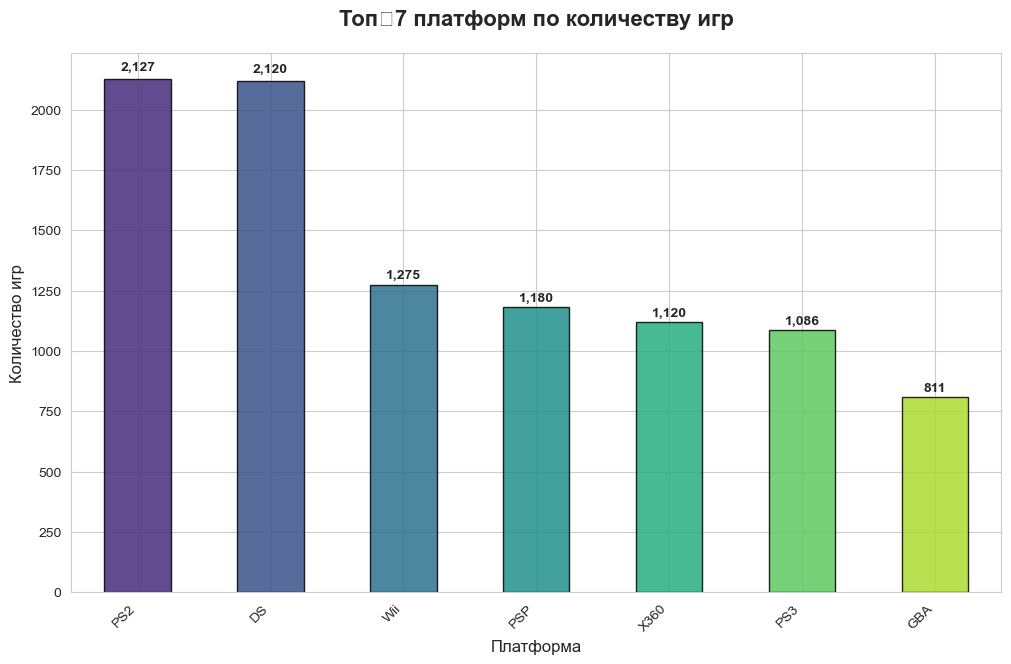

In [34]:
platform_counts.head(7)
sns.set_style("whitegrid")
plt.figure(figsize=(12, 7))

# Создаём диаграмму с градиентом
colors = sns.color_palette("viridis", 7)
ax = platform_counts.head(7).plot.bar(
    color=colors,
    edgecolor='black',
    linewidth=1,
    alpha=0.85
)

# Настройки графика
plt.title('Топ‑7 платформ по количеству игр', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Платформа', fontsize=12)
plt.ylabel('Количество игр', fontsize=12)

# Добавляем значения над столбцами
for i, v in enumerate(platform_counts.head(7)):
    ax.text(i, v + v * 0.01, f'{v:,}', ha='center', va='bottom',
             fontweight='bold', fontsize=10)


plt.xticks(rotation=45, ha='right')

plt.show()

- Выделите топ-7 платформ по количеству игр, выпущенных за весь актуальный период.

In [35]:
df_actual.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,user_score_cut,critic_score_cut
0,wii sports,Wii,2006-01-01,sports,41.36,28.96,3.77,8.45,76.0,8.0,E,Высокая оценка,средняя оценка
2,mario kart wii,Wii,2008-01-01,racing,15.68,12.76,3.79,3.29,82.0,8.3,E,Высокая оценка,Высокая оценка
3,wii sports resort,Wii,2009-01-01,sports,15.61,10.93,3.28,2.95,80.0,8.0,E,Высокая оценка,Высокая оценка
6,new super mario bros.,DS,2006-01-01,platform,11.28,9.14,6.50,2.88,89.0,8.5,E,Высокая оценка,Высокая оценка
7,wii play,Wii,2006-01-01,misc,13.96,9.18,2.93,2.84,58.0,6.6,E,средняя оценка,средняя оценка


Определим количество игр, каждого жанра в разрезе локации.

In [36]:
genre_sales = df_actual.groupby('genre').agg({'na_sales': 'sum',
                                'eu_sales': 'sum',
                                'jp_sales': 'sum',
                                'other_sales': 'sum'
                               }
    )
display(genre_sales)

,na_sales,eu_sales,jp_sales,other_sales
genre,,,,
action,679.74,390.170708,102.642721,152.51
adventure,76.49,43.010000,33.740000,12.95
fighting,148.34,67.820000,38.531322,29.00
misc,350.22,183.413883,79.891260,66.91
platform,250.76,132.780449,52.583060,39.79
puzzle,63.50,39.230000,23.250000,10.01
racing,262.57,177.700000,25.960000,65.98
role-playing,248.83,127.520000,210.550000,42.88
shooter,416.21,228.500000,18.410000,78.64


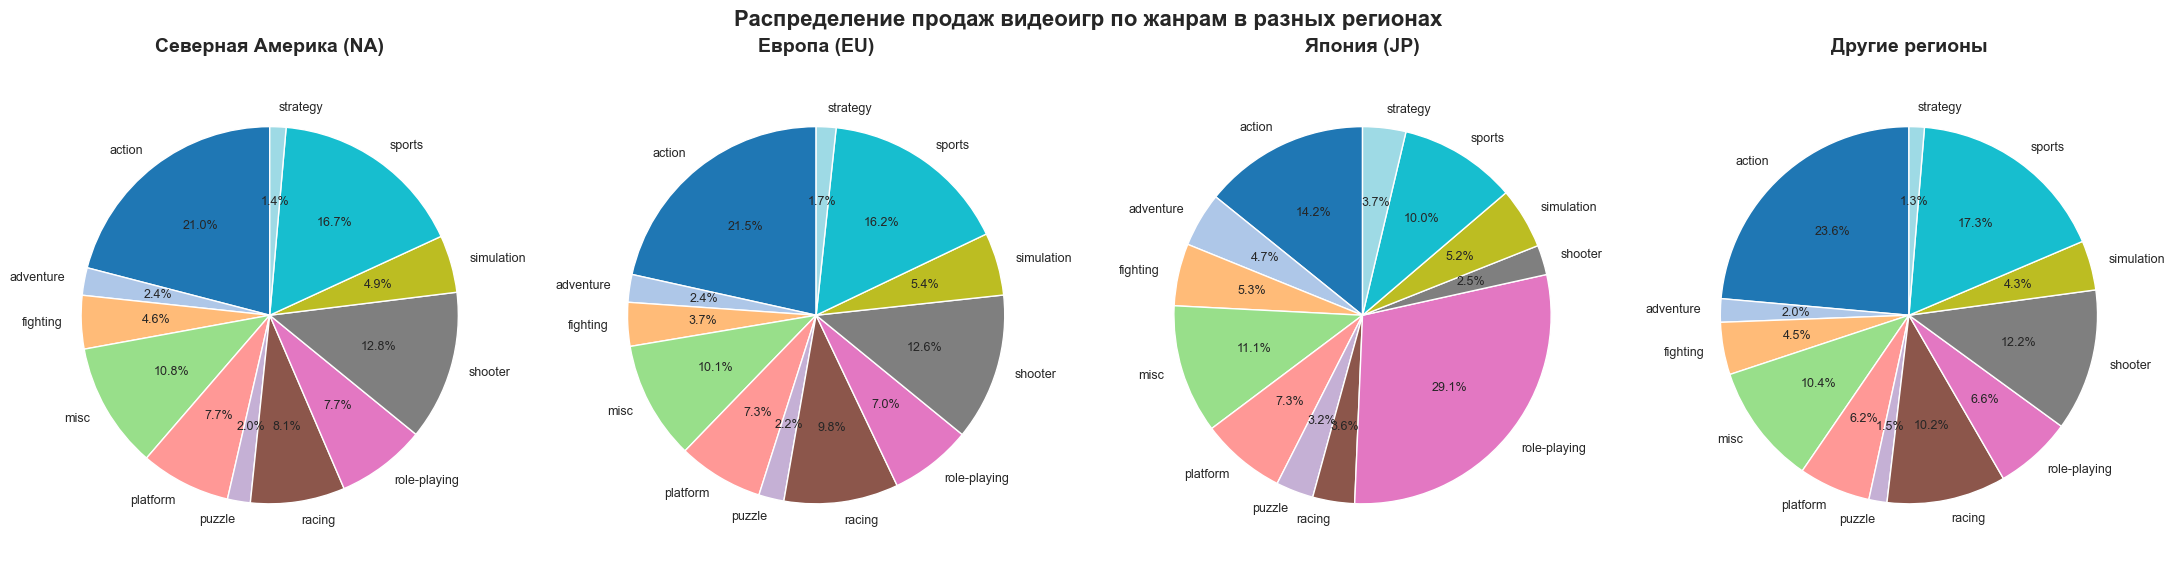

In [37]:
# Настраиваем стиль графиков
plt.style.use('seaborn-v0_8-whitegrid')

# Создаём фигуру с 4 подграфиками (1 строка, 4 столбца)
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
regions = ['na_sales', 'eu_sales', 'jp_sales', 'other_sales']
titles = ['Северная Америка (NA)', 'Европа (EU)', 'Япония (JP)', 'Другие регионы']

# Цвета для жанров (одинаковые на всех диаграммах для сравнения)
colors = plt.cm.tab20(np.linspace(0, 1, len(genre_sales)))

for i, (region, title) in enumerate(zip(regions, titles)):
    # Данные для текущего региона
    sales_data = genre_sales[region]
    
    # Удаляем жанры с нулевыми/почти нулевыми продажами для лучшей читаемости
    mask = sales_data > 0
    sales_filtered = sales_data[mask]
    
    # Исправленный способ получения цветов: используем индексы отфильтрованных данных
    indices = sales_filtered.index
    colors_filtered = [colors[genre_sales.index.get_loc(genre)] for genre in indices]
    
    # Строим круговую диаграмму
    axes[i].pie(
        sales_filtered,
        labels=sales_filtered.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors_filtered,
        textprops={'fontsize': 9}
    )
    axes[i].set_title(title, fontsize=14, fontweight='bold', pad=20)

plt.suptitle('Распределение продаж видеоигр по жанрам в разных регионах',
           fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_7468\547556393.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  colors_filtered = [colors[j] for j in range(len(sales_data)) if mask[j]]


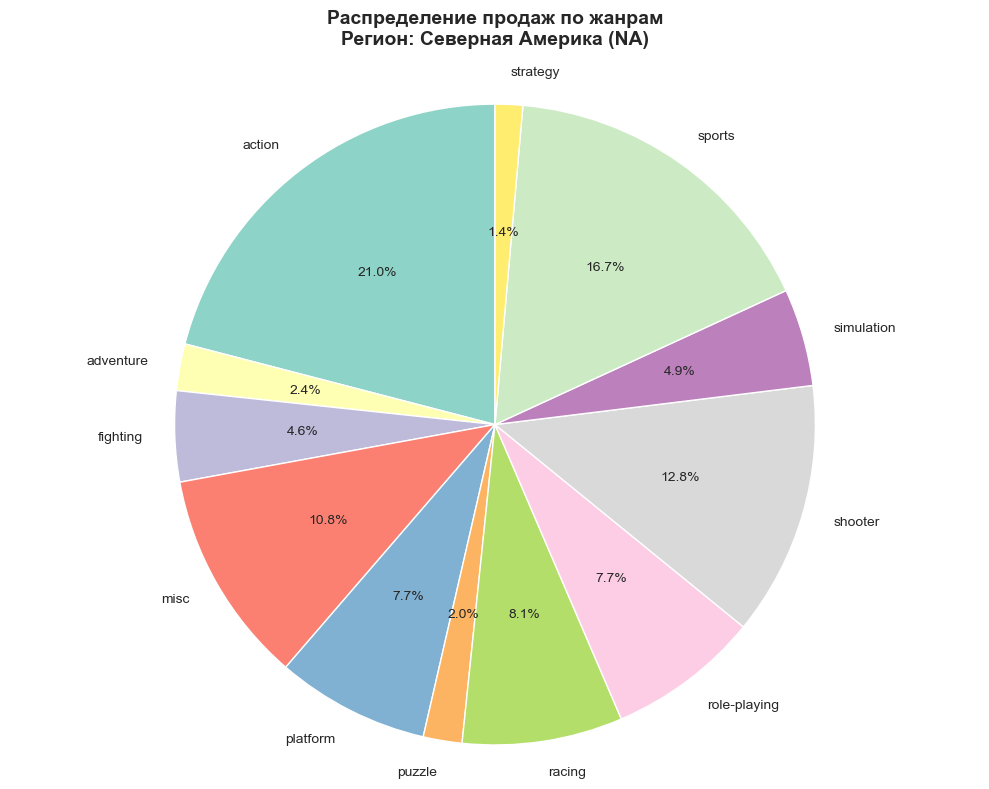

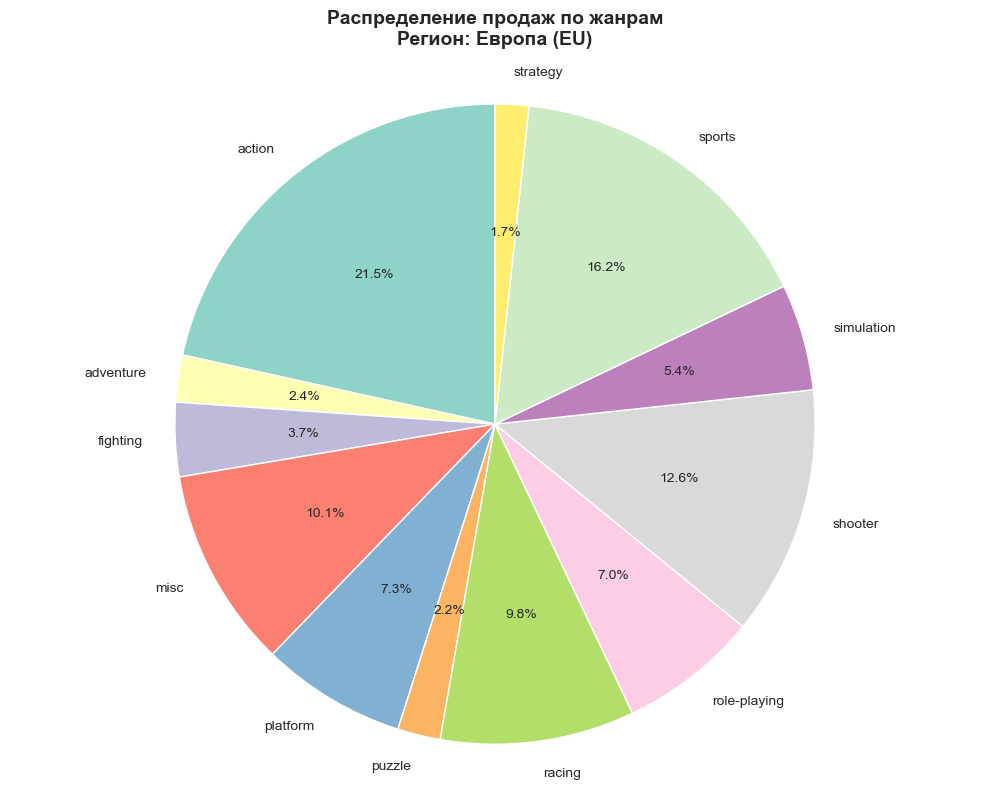

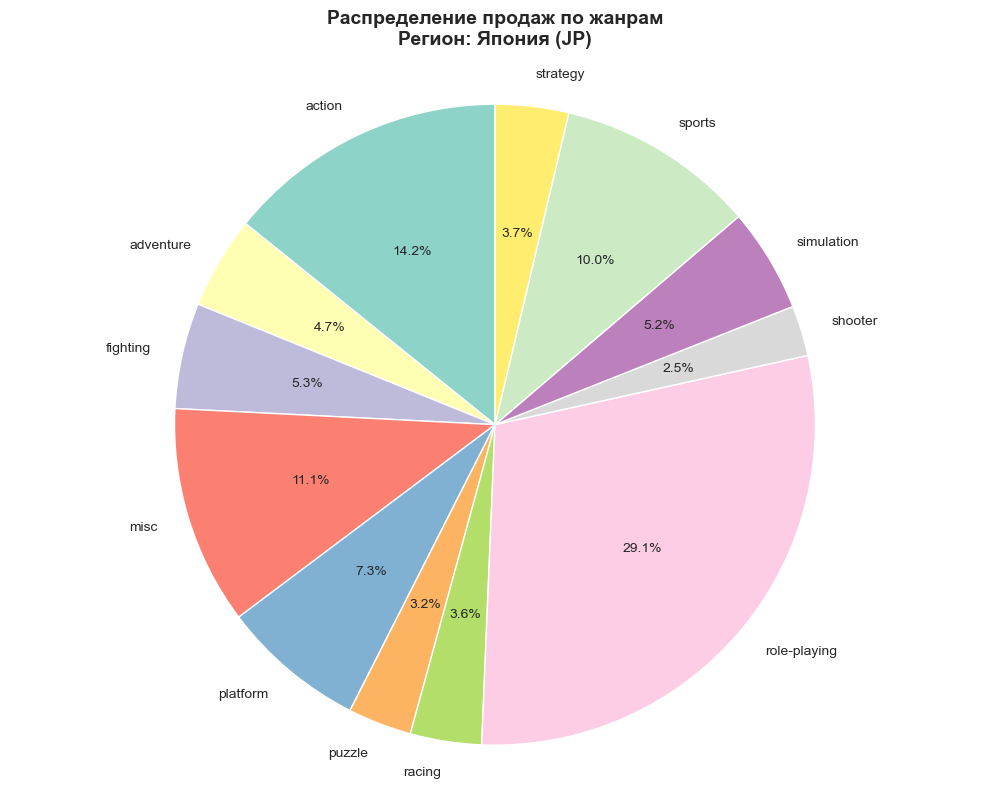

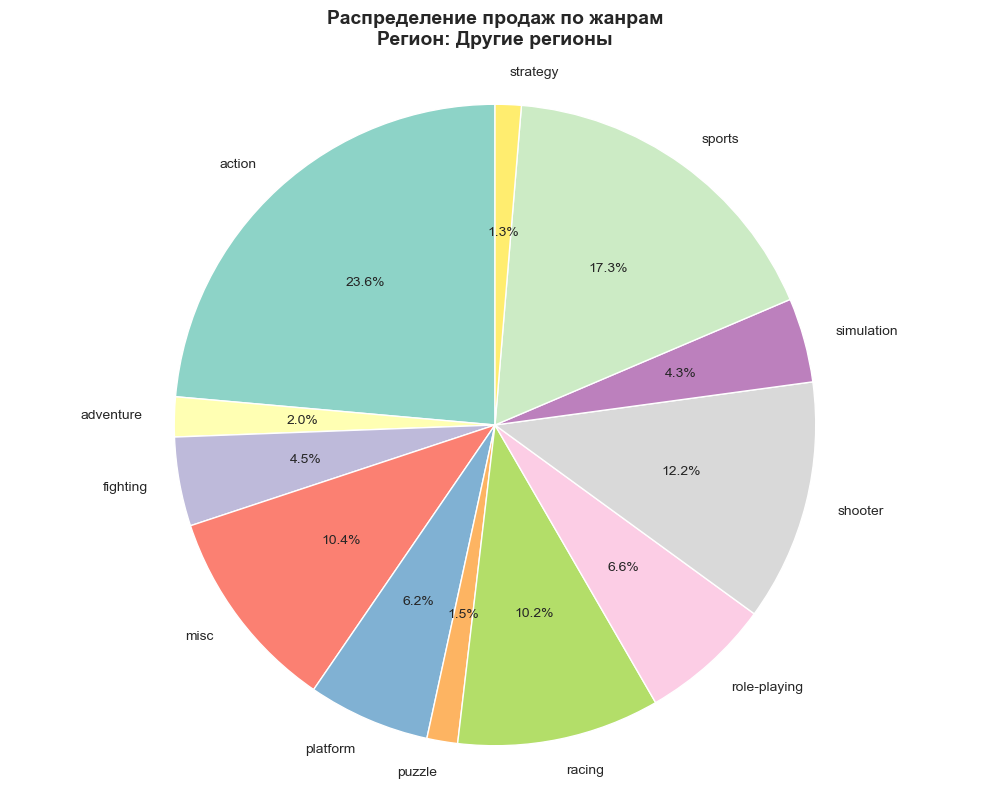

In [38]:
#Более детальное представление
regions = ['na_sales', 'eu_sales', 'jp_sales', 'other_sales']
titles = ['Северная Америка (NA)', 'Европа (EU)', 'Япония (JP)', 'Другие регионы']
colors = plt.cm.Set3(np.linspace(0, 1, len(genre_sales)))

for region, title in zip(regions, titles):
    plt.figure(figsize=(10, 8))
    sales_data = genre_sales[region]
    mask = sales_data > 0
    sales_filtered = sales_data[mask]
    colors_filtered = [colors[j] for j in range(len(sales_data)) if mask[j]]

    plt.pie(
        sales_filtered,
        labels=sales_filtered.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors_filtered,
        textprops={'fontsize': 10}
    )
    plt.title(f'Распределение продаж по жанрам\nРегион: {title}', fontsize=14, fontweight='bold', pad=20)
    plt.axis('equal')  # Для идеального круга
    plt.tight_layout()
    plt.show()

**Вывод по продажам видеоигр по жанрам и регионам**
Анализ данных о продажах видеоигр по жанрам в четырёх регионах (Северная Америка — `NA`, Европа — `EU`, Япония — `JP`, другие регионы — `Other`) позволяет выделить ключевые закономерности.

Общие наблюдения  
- Лидер по продажам — жанр Action: суммарно он доминирует во всех регионах, особенно в Северной Америке (679,74 млн) и Европе (390,17 млн).
- Аутсайдеры — жанры Adventure и Strategy, с минимальными продажами во всех регионах.

Региональные различия ярко выражены:

- Северная Америка — основной рынок для большинства жанров.

- Япония — специфический рынок: здесь заметно выше доля Role‑Playing (210,55 млн) по сравнению с другими регионами.

- Европа — второй по значимости рынок, с сильной корреляцией продаж с Северной Америкой.

- Другие регионы — относительно небольшой вклад, но заметный для отдельных жанров (например, Racing).

---

## 5. Итоговый вывод



В ходе работы была проделана полная предобработка датасета, все типы данных были приведены к рациональным для их дальнейшей обработки. Были удалены и заменены пропуски значений без критических изменений датасета, влияющих на дальнейшую обработку и обучение модели. Были выявлены дубликаты с дальнейшем их удалением и приведением датасета к корректному виду. После фильтрации данных по необходимому для нас диапазону даты выхода игр, добавлены два новых поля с категориями, выставлявшимися на основании оценок критиков и пользователей, и используемых в дальнейшем для группировки и подсчета колличества игр в каждой категории с выявлением самым востребованных для пользователей платформ выхода игр.

**Итоговые выводы**
**Аудитория и критика:**

- пользователи более лояльны, чем критики, и чаще ставят высокие оценки;

- значительная часть игр игнорируется — это создаёт возможности для продвижения нишевых проектов.

**Региональные предпочтения:**

- Северная Америка и Европа схожи по жанровым предпочтениям (Action, Sports);

- Япония требует отдельной стратегии (фокус на Role‑Playing);

- «Другие регионы» — перспективный рынок для Racing и мультиплатформенных релизов.

**Жанры‑лидеры:**

- Action — универсальный выбор для глобального релиза;

- Role‑Playing — ключевой жанр для азиатского рынка;

- Sports и Racing — сильные позиции в западном мире.

**Потенциал роста:**

- гибридные жанры могут объединить аудиторию разных направлений;

- локальные адаптации (например, локализация RPG для Запада) дадут синергию.

**Общий итог:** данные подтверждают необходимость сегментации стратегий по регионам и жанрам. Успех зависит от учёта лояльности пользователей, специфики рынков и грамотного распределения ресурсов между массовыми и нишевыми проектами.

**Рекомендации:**

Для издателей:

фокусироваться на Action и Sports для глобальных релизов;

локализовать Role‑Playing для японского рынка;

тестировать Racing и Shooter в Северной Америке и Европе.

Для маркетологов:

адаптировать кампании под регионы: в Японии делать акцент на RPG‑элементы, в США — на динамичный геймплей;

использовать данные по «другим регионам» для выхода на новые рынки.

Для разработчиков:

инвестировать в гибридные жанры (например, Action‑RPG), объединяющие сильные стороны разных направлений;

пересмотреть стратегию для Adventure и Strategy: возможно, переориентация на мобильные платформы или кооперативные механики повысит спрос.